This notebook will build a predictive model to forecast PM2.5 Models.

By forecasting PM2.5 Levels it allows Lagos state government and its residents plan ahead for the future.

I will make use of 2 predictive models to predict PM2.5 models:
1. Linear Regression(basic)
2. Random Forest(advance)

**Linear Regression**: Regression models relationships between a continuous target variable and explanatory features, covering simple and multiple regression types. In this case, multiple regression will be utilised to as multiple features will be used to predict the PM2.5 values

The aim is to see if a simple model that does not consider outside environmental factors can accurately predict PM2.5 levels

**Random Forest**: Random Forest uses many decision trees to make better predictions. It can capture non-linear relationships, display feature importance and more robust to noise

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#importing data
data = pd.read_csv("cleaned_data.csv")

data.head()

,PM2.5,PM10,Temp,Humidity,hour,pm25_lag_1,pm25_lag_2,temp_lag_1
0,41.4500,51.20,29.875,92.07,2,41.35,41.25,30.100
1,41.5500,51.80,29.650,93.58,3,41.45,41.35,29.875
2,41.6500,52.40,29.425,95.09,4,41.55,41.45,29.650
3,41.7500,53.00,29.200,96.60,5,41.65,41.55,29.425
4,39.8125,49.75,30.150,92.40,6,41.75,41.65,29.200


## Linear Regression Model

In [13]:
# Define Features (X) and Target (y)
features = ['hour', 'pm25_lag_1', 'pm25_lag_2', 'Temp', 'Humidity', 'temp_lag_1']
X = data[features]
y = data['PM2.5']

#Standardise Features (0-1) to ensure all features contribute equally
X_norm = StandardScaler().fit(X).transform(X)

#Split Data
cutoff = int(len(X) * 0.8)
X_train = X_norm[:cutoff]
X_test = X_norm[cutoff:]
y_train = y[:cutoff]
y_test = y[cutoff:]


#Train Linear Regression Model and Predict Data
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Evaluation & Predition
y_pred_lr = lr_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.4f} µg/m³")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

R2 Score: 0.8457
MAE: 3.5675 µg/m³
Root Mean Squared Error: 5.9877


The Linear Regression Model achieved an R2 score of 0.8457, in other words a Linear regression model can predict approximately 84.6% of the variation of PM2.5 Values.

The Model also has an MAE (mean absolute error) score of 3.5675, meaning that the prediction values differ from the actual values on average 3.5675 µg/m³

The Model RME is 5.9877.
Root Mean Squared Error punishes big mistakes as it is sensitive to spikes. The RMSE score is higher than the MAE because the model is **failing** to take into account for huge spikes

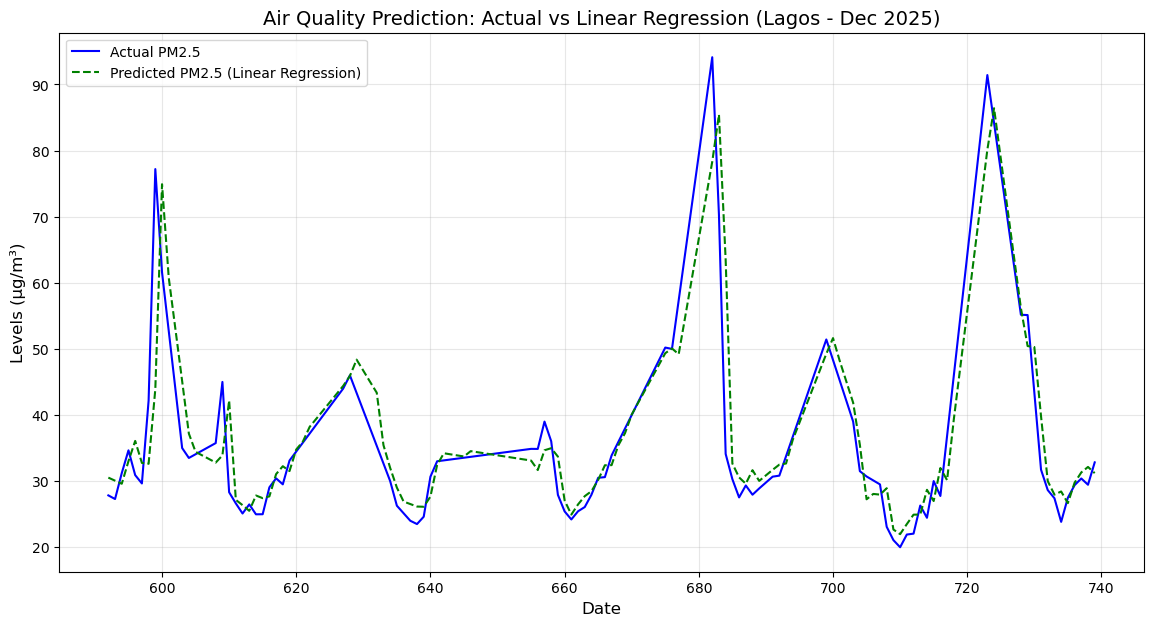

In [4]:
#Plotting the Graph
plt.figure(figsize=(14, 7))

plt.plot(y_test.index, y_test.values, label='Actual PM2.5', color='blue', linewidth=1.5)

plt.plot(y_test.index, y_pred_lr, label='Predicted PM2.5 (Linear Regression)', 
         color='green', linestyle='--', linewidth=1.5)

plt.title('Air Quality Prediction: Actual vs Linear Regression (Lagos - Dec 2025)', fontsize=14)
plt.ylabel('Levels (µg/m³)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Linear Regression Prediction Graph.png')

plt.show()

In [5]:
coef_ =  lr_model.coef_
intercept_ = lr_model.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)

Coefficients:  [-0.27653322 14.81336803 -0.10091318 -3.87855384 -1.27078171  0.88100863]
Intercept:  41.082659187418045


Coefficient shows how much target y (PM2.5 Levels) is influenced by the features and the intercept is the base value of y (PM 2.5 levels) when all values are 0.

These numbers can be better displayed using a graph to clearly state which features contribute the most

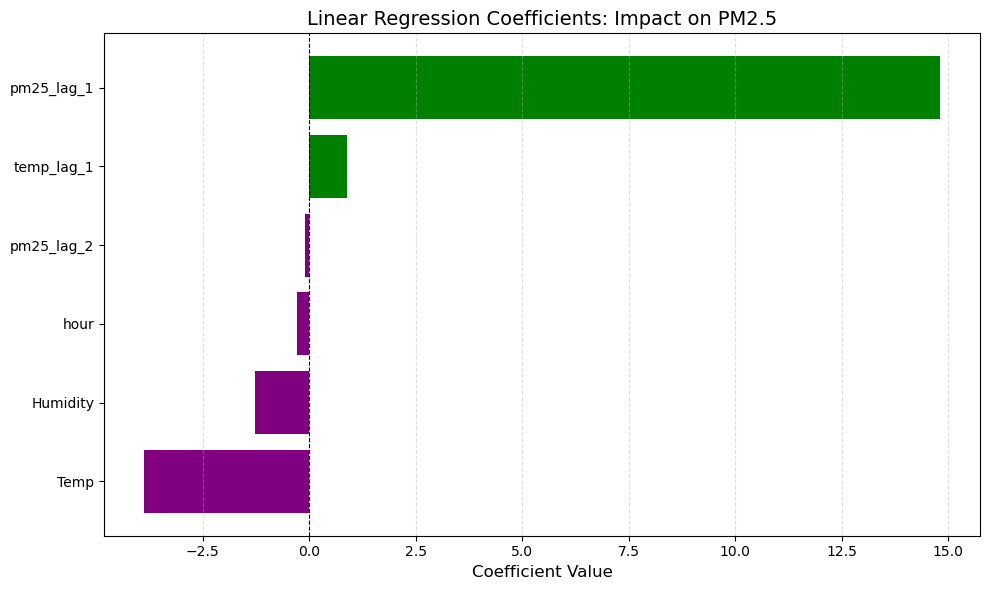

In [6]:
#PLotting the Coefficient graph
#Create a new DataFrame for ease
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coef_})
coef_df = coef_df.sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))


# Use different colors for positive and negative impacts
colors = ['purple' if x < 0 else 'green' for x in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.title('Linear Regression Coefficients: Impact on PM2.5', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('linear_regression_coefficients.png')
plt.show()

The graph shows that PM2.5 values in the last hour and the environmental temperature are the key features affecting the PM2.5 levels in Lagos. T

## Random Forest Model

In [14]:
# Define Features (X) and Target (y)
features = ['hour', 'pm25_lag_1', 'pm25_lag_2', 'Temp', 'Humidity', 'temp_lag_1']
X = data[features]
y = data['PM2.5']

#Split Data
cutoff = int(len(X) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

# Train Random Forest Regressor and Predict Data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Evaluation & Predition
y_pred_rf = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.4f} µg/m³")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

R2 Score: 0.8559
MAE: 3.3453 µg/m³
Root Mean Squared Error: 5.7865


The Random Forest Model achieved an R2 score of 0.8559, in other words a Linear regression model can predict approximately 85.6% of the variation of PM2.5 Values.

The Model also has an MAE (mean absolute error) score of 3.3453, meaning that the prediction values differ from the actual values on average 3.3453 µg/m³

The Model RME is 5.7865.
Random Forest Model has a slightly better RMSE score but the issues remain as it also fails to accurately account for spikes

The Random Forest Model performs better as expected but the evaluation metrics show the difference in result are not so different from the Linear Regression Model

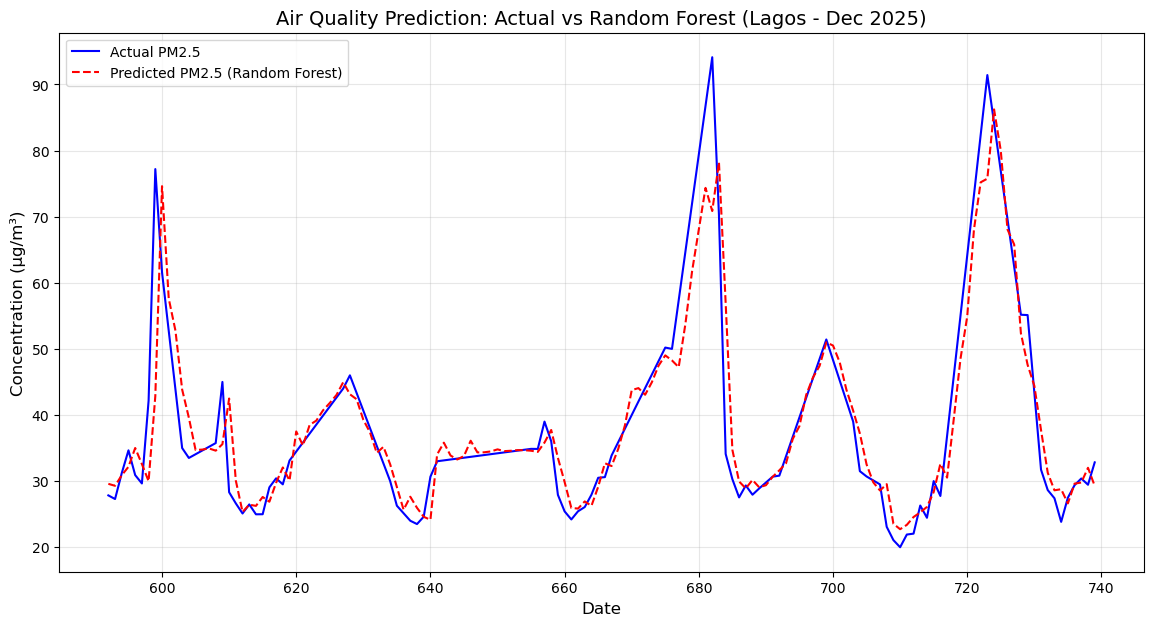

In [8]:
#Plotting the Graph
plt.figure(figsize=(14, 7))

plt.plot(y_test.index, y_test.values, label='Actual PM2.5', color='blue', linewidth=1.5)

plt.plot(y_test.index, y_pred_rf, label='Predicted PM2.5 (Random Forest)', 
         color='red', linestyle='--', linewidth=1.5)

plt.title('Air Quality Prediction: Actual vs Random Forest (Lagos - Dec 2025)', fontsize=14)
plt.ylabel('Concentration (µg/m³)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Random Forest Prediction Graph.png')

plt.show()

With a feature importance graph, government regulators can see which values influence pm2.5 emissions the most

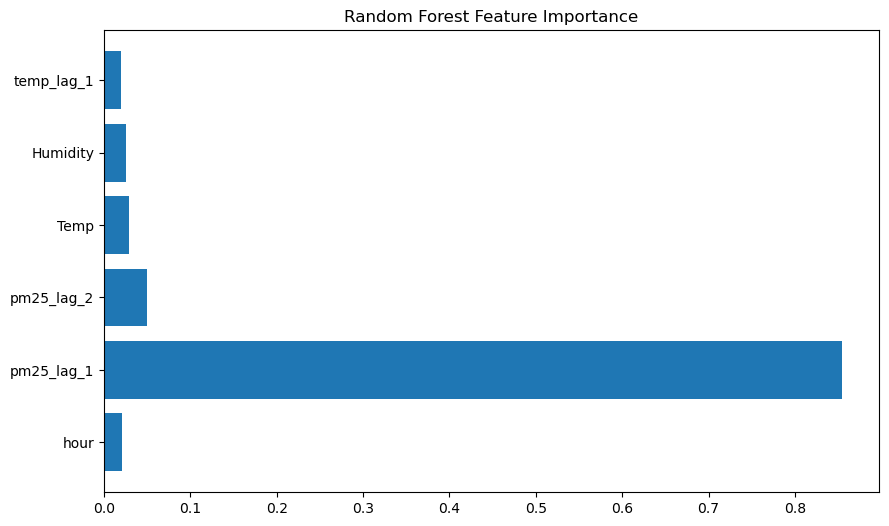

In [9]:
#feature importance
importance = model.feature_importances_
features = X.columns

#PLot Feature importance
plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Random Forest Feature Importance")
plt.savefig('Feature Importance Graph.png')

plt.show()


PM2.5 Lag(1) Values -PM2.5 values an hour before- is shown to be the major predictor of present PM2.5 values

PM2.5 Values are easy to predict if the values of an hour before are available as there is not change in the atmosphere within an hour.

## Limitations and Challenges
1. Lagging data was required to get an accurate model as earlier features were not strong enough to forecast values accurately
2. Data was only limited to Maryland as opposed to the whole of Lagos as was initially planned
3. Neither the Linear Regression model nor Random Forest was able to efficiently capture sudden spikes in the morning
4. Model does not account for external factors such as harmattan and holidays(Detty December)

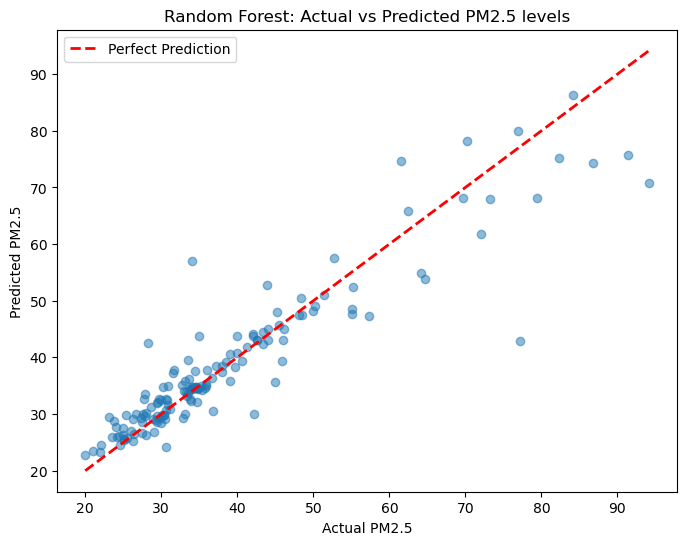

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)


plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')
plt.title('Random Forest: Actual vs Predicted PM2.5 levels')
plt.legend()


plt.savefig('Random Forest - Actual vs Predicted PM2.5 levels.png')
plt.show()


